In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("smart_hospital_appointment_dataset.csv")

df.head()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,PAT_10001,21,Female,Mumbai,25.3,NaN,Scheduled,Neurology,Headache,Low,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,PAT_10002,51,Female,Bangalore,21.9,NaN,Scheduled,Dermatology,Skin Allergy,Low,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,PAT_10003,78,Female,Delhi,31.7,NaN,Walk-in,Orthopedics,Joint Pain,Low,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed


In [15]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset: (10000, 26)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  str    
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  str    
 3   city                          10000 non-null  str    
 4   bmi                           10000 non-null  float64
 5   chronic_disease               5550 non-null   str    
 6   appointment_type              10000 non-null  str    
 7   department                    10000 non-null  str    
 8   symptoms                      10000 non-null  str    
 9   severity_level                10000 non-null  str    
 10  doctor_experience_years       10000 non-null  int64  
 11  consultation_fee              10000 non-null  int64  
 12  insurance           

,age,bmi,doctor_experience_years,consultation_fee,booking_to_appointment_days,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.000400,24.010890,15.399000,606.860700,12.754500,25.203900,7.019200,1.416700,3.989940,0.148600,9.701980,5053.976100,3932.363100,7881.768000
std,25.862836,3.935325,8.604069,180.246694,9.405715,14.862961,4.334502,1.383637,0.579424,0.355712,0.537897,5618.208887,4165.875586,7904.071155
min,1.000000,15.000000,1.000000,220.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,7.600000,100.000000,0.000000,331.800000
25%,22.000000,21.300000,8.000000,461.000000,4.000000,13.000000,3.000000,0.000000,3.500000,0.000000,9.600000,758.750000,748.000000,1598.100000
50%,45.000000,24.000000,15.000000,609.000000,12.000000,23.000000,7.000000,1.000000,4.000000,0.000000,10.000000,2833.000000,2345.000000,4631.550000
75%,68.000000,26.700000,23.000000,752.000000,21.000000,35.000000,11.000000,2.000000,4.500000,0.000000,10.000000,7499.500000,5817.500000,13280.000000
max,89.000000,39.800000,30.000000,999.000000,29.000000,59.000000,14.000000,9.000000,5.000000,1.000000,10.000000,19996.000000,14992.000000,34894.000000


In [16]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

patient_id                         0
age                                0
gender                             0
city                               0
bmi                                0
chronic_disease                 4450
appointment_type                   0
department                         0
symptoms                           0
severity_level                     0
doctor_experience_years            0
consultation_fee                   0
insurance                          0
appointment_day                    0
appointment_month                  0
booking_to_appointment_days        0
waiting_time_minutes               0
previous_appointments              0
missed_previous_appointments       0
hospital_rating                    0
emergency_case                     0
patient_satisfaction_score         0
medicine_cost                      0
test_cost                          0
total_bill                         0
appointment_status                 0
dtype: int64


In [19]:
df['chronic_disease'] = df['chronic_disease'].fillna('None')
print(df['chronic_disease'].isnull().sum())

0


In [20]:
print(df['chronic_disease'].value_counts())

chronic_disease
None             4450
Diabetes         2034
Hypertension     2018
Asthma           1018
Heart Disease     480
Name: count, dtype: int64


In [21]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


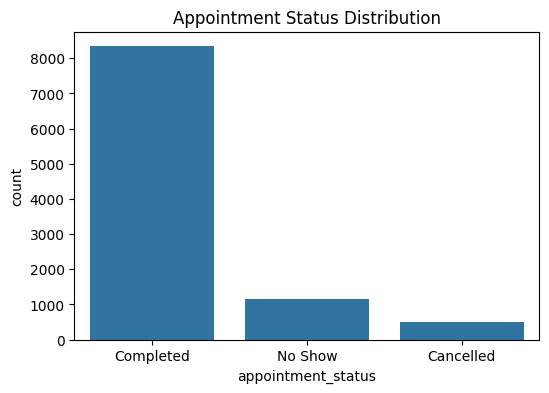

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x='appointment_status', data=df)

plt.title("Appointment Status Distribution")
plt.show()

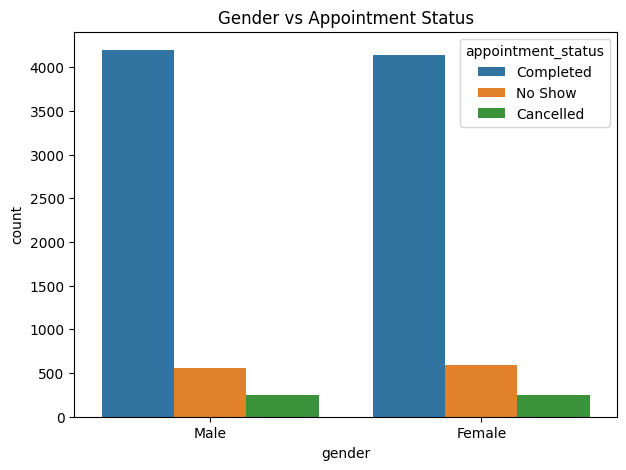

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='gender',
    hue='appointment_status',
    data=df
)

plt.title("Gender vs Appointment Status")
plt.show()

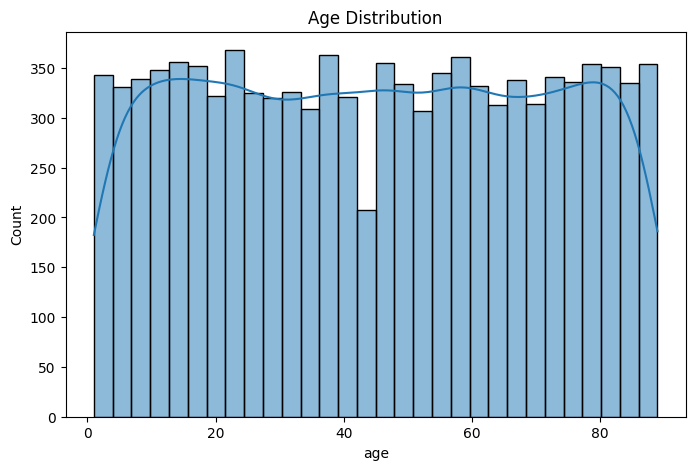

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

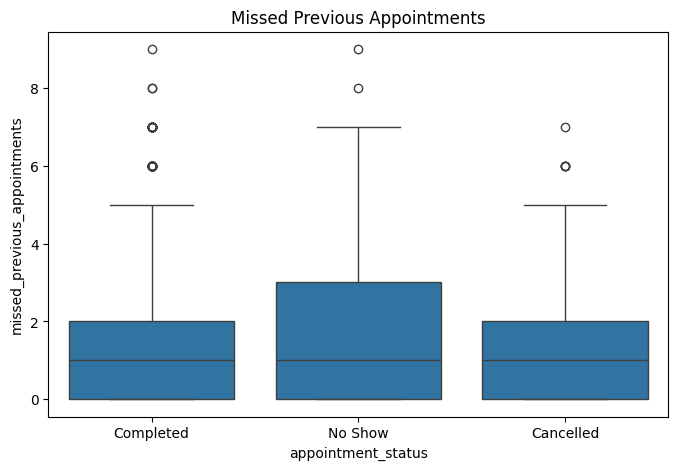

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='appointment_status',
    y='missed_previous_appointments',
    data=df
)

plt.title("Missed Previous Appointments")
plt.show()

In [26]:
df.drop('patient_id', axis=1, inplace=True)

In [28]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
df.head()

,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,doctor_experience_years,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,19,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,21,Female,Mumbai,25.3,None,Scheduled,Neurology,Headache,Low,1,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,51,Female,Bangalore,21.9,None,Scheduled,Dermatology,Skin Allergy,Low,18,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,78,Female,Delhi,31.7,None,Walk-in,Orthopedics,Joint Pain,Low,17,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,15,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed


In [52]:
from sklearn.preprocessing import LabelEncoder

# Create a separate encoder for each column
for col in df.select_dtypes(include='object').columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))

C:\Users\Dhruva\AppData\Local\Temp\ipykernel_23164\918732018.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [53]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='str')


In [54]:
X = df.drop('appointment_status', axis=1)

y = df['appointment_status']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
for col in X.columns:
    print(col, ":", X[col].dtype)

age : int64
gender : int64
city : int64
bmi : float64
chronic_disease : int64
appointment_type : int64
department : int64
symptoms : int64
severity_level : int64
doctor_experience_years : int64
consultation_fee : int64
insurance : int64
appointment_day : int64
appointment_month : int64
booking_to_appointment_days : int64
waiting_time_minutes : int64
previous_appointments : int64
missed_previous_appointments : int64
hospital_rating : float64
emergency_case : int64
patient_satisfaction_score : float64
medicine_cost : int64
test_cost : int64
total_bill : float64


In [57]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='str')


#ACCURACY

In [58]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.84


c:\Users\Dhruva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)


KNN Accuracy: 0.8265


In [60]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7055


In [61]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'KNN',
              'Decision Tree'],
    'Accuracy': [lr_accuracy,
                 knn_accuracy,
                 dt_accuracy]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8400
1                  KNN    0.8265
2        Decision Tree    0.7055


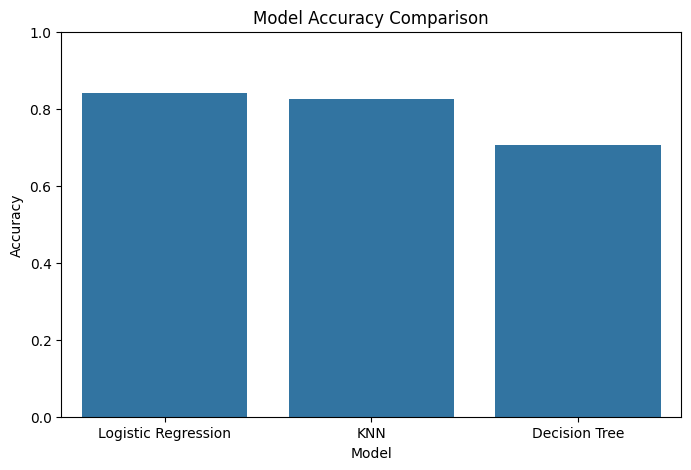

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

In [63]:
import pickle

pickle.dump(knn, open('model.pkl', 'wb'))

print("KNN Model Saved Successfully!")

KNN Model Saved Successfully!


In [64]:
print(list(X_train.columns))

['age', 'gender', 'city', 'bmi', 'chronic_disease', 'appointment_type', 'department', 'symptoms', 'severity_level', 'doctor_experience_years', 'consultation_fee', 'insurance', 'appointment_day', 'appointment_month', 'booking_to_appointment_days', 'waiting_time_minutes', 'previous_appointments', 'missed_previous_appointments', 'hospital_rating', 'emergency_case', 'patient_satisfaction_score', 'medicine_cost', 'test_cost', 'total_bill']
